In [2]:
import numpy as np
from pathlib import Path

# Set the path to the processed data
processed_dir = Path(
    r"E:\data of brain projec\data of brain project\EEG_project\processed_data"
)

# Load subject and trial information
subjects = np.load(processed_dir / "subjects.npy")
trials = np.load(processed_dir / "trials.npy")

# Load connectivity matrices
correlation = np.load(processed_dir / "correlation.npy")
mi = np.load(processed_dir / "mi.npy")

print("Subjects shape:", subjects.shape)
print("Trials shape:", trials.shape)
print("Correlation shape:", correlation.shape)
print("MI shape:", mi.shape)

Subjects shape: (85330,)
Trials shape: (85330,)
Correlation shape: (85330, 14, 14)
MI shape: (85330, 14, 14)


In [3]:
# Select one Subject-Trial for testing
TEST_SUBJECT = 1
TEST_TRIAL = 1

# Find all windows belonging to the selected Subject-Trial
test_mask = (
    (subjects == TEST_SUBJECT) &
    (trials == TEST_TRIAL)
)

trial_indices = np.where(test_mask)[0]

# Extract the dynamic connectivity matrices
trial_corr = correlation[trial_indices]
trial_mi = mi[trial_indices]

print("Subject:", TEST_SUBJECT)
print("Trial:", TEST_TRIAL)
print("Number of windows:", len(trial_indices))

print("\nCorrelation shape:", trial_corr.shape)
print("MI shape:", trial_mi.shape)

Subject: 1
Trial: 1
Number of windows: 198

Correlation shape: (198, 14, 14)
MI shape: (198, 14, 14)


In [4]:
# Create a topology mask for the 14 EEG channels

num_nodes = 14

# Start with a fully connected topology
topology_mask = np.ones((num_nodes, num_nodes), dtype=np.float32)

# Remove self-connections
np.fill_diagonal(topology_mask, 0)

print("Topology mask shape:", topology_mask.shape)
print("Number of possible edges:", int(topology_mask.sum()))

Topology mask shape: (14, 14)
Number of possible edges: 182


In [7]:
for i in range(14):
    print(topology_mask[i])

[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# 14 EEG channels
# The row/column index is our fixed internal node ID.
# ============================================================

channels = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

# ============================================================
# EEG graph topology
#
# 1 = an edge exists
# 0 = no edge
#
# The graph is undirected, therefore:
# topology[i,j] = topology[j,i]
# Self-connections are removed.
# ============================================================

topology = np.zeros((14, 14), dtype=np.float32)

# -------- Left hemisphere / central connections --------

edges = [
    # Frontal
    ("AF3", "F7"),
    ("AF3", "F3"),
    ("AF3", "F4"),
    ("AF3", "F8"),
    ("AF3", "AF4"),

    ("F7", "F3"),
    ("F7", "FC5"),
    ("F7", "T7"),

    ("F3", "FC5"),
    ("F3", "F4"),
    ("F3", "FC6"),

    # Left temporal / parietal
    ("FC5", "T7"),
    ("FC5", "P7"),

    ("T7", "P7"),
    ("T7", "T8"),

    ("P7", "O1"),
    ("P7", "P8"),

    ("O1", "O2"),

    # Right temporal / parietal
    ("O2", "P8"),
    ("P8", "T8"),
    ("P8", "FC6"),

    ("T8", "FC6"),

    # Right frontal
    ("FC6", "F4"),
    ("FC6", "F8"),

    ("F4", "F8"),
    ("F4", "AF4"),

    ("F8", "AF4"),

    # Left-right homologous connections
    ("F7", "F8"),
    ("F3", "F4"),
    ("FC5", "FC6"),
    ("T7", "T8"),
    ("P7", "P8"),
    ("O1", "O2"),
]

# Convert channel names to indices
channel_to_idx = {ch: i for i, ch in enumerate(channels)}

# Fill adjacency matrix
for ch1, ch2 in edges:
    i = channel_to_idx[ch1]
    j = channel_to_idx[ch2]

    topology[i, j] = 1
    topology[j, i] = 1

# No self-connections
np.fill_diagonal(topology, 0)

print("Topology shape:", topology.shape)
print("Number of undirected edges:", int(topology.sum() / 2))

Topology shape: (14, 14)
Number of undirected edges: 29


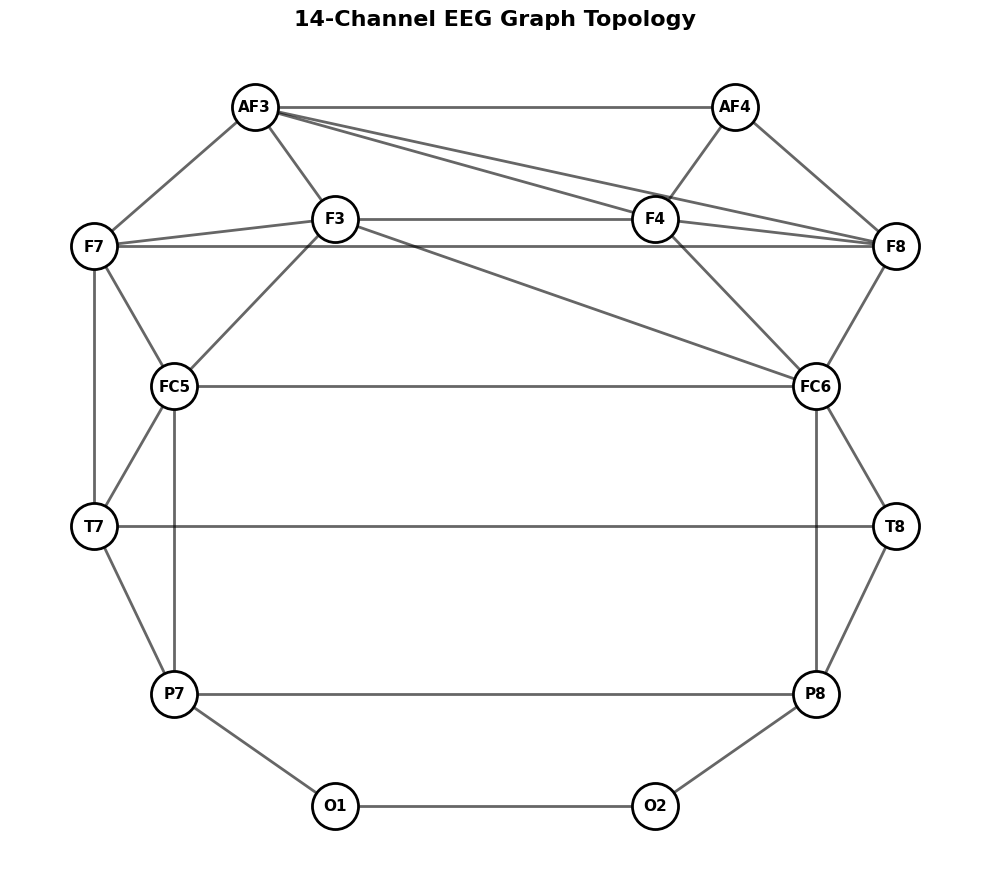

In [12]:
# ============================================================
# Visualize EEG Graph Topology
# ============================================================

G = nx.Graph()

# Add nodes
for i, channel in enumerate(channels):
    G.add_node(channel)

# Add edges from topology matrix
for i in range(14):
    for j in range(i + 1, 14):
        if topology[i, j] == 1:
            G.add_edge(channels[i], channels[j])

# ------------------------------------------------------------
# Approximate 2D scalp positions
# This is only for visualization.
# It does NOT change the graph topology.
# ------------------------------------------------------------

pos = {
    "AF3": (-1.5, 3.0),
    "F7":  (-2.5, 2.0),
    "F3":  (-1.0, 2.2),
    "FC5": (-2.0, 1.0),
    "T7":  (-2.5, 0.0),
    "P7":  (-2.0, -1.2),
    "O1":  (-1.0, -2.0),

    "AF4": (1.5, 3.0),
    "F8":  (2.5, 2.0),
    "F4":  (1.0, 2.2),
    "FC6": (2.0, 1.0),
    "T8":  (2.5, 0.0),
    "P8":  (2.0, -1.2),
    "O2":  (1.0, -2.0),
}

plt.figure(figsize=(10, 9))

nx.draw_networkx_edges(
    G,
    pos,
    width=2,
    alpha=0.6
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1100,
    node_color="white",
    edgecolors="black",
    linewidths=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=11,
    font_weight="bold"
)

plt.title(
    "14-Channel EEG Graph Topology",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
for i in range(14):
    print(topology[i])

[0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]
[1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
[1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
[0. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0.]
[0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0.]
[0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
[0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0.]
[1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1.]
[1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]


In [15]:
# EEG Topology Matrix
#
# Each ROW and COLUMN represents the same EEG electrode.
#
# Index → Electrode
#
# 0  → AF3
# 1  → F7
# 2  → F3
# 3  → FC5
# 4  → T7
# 5  → P7
# 6  → O1
# 7  → O2
# 8  → P8
# 9  → T8
# 10 → FC6
# 11 → F4
# 12 → F8
# 13 → AF4
#
# Matrix meaning:
#
# topology[i, j] = 1
#     → An edge exists between electrode i and electrode j.
#
# topology[i, j] = 0
#     → No edge exists between electrode i and electrode j.
#
# The matrix is symmetric because the graph is undirected:
#
# topology[i, j] == topology[j, i]
#
# The diagonal is zero because a node is not connected to itself:
#
# topology[i, i] = 0
#
# Example:
#
# topology[0, 1] = 1
#     → AF3 is connected to F7
#
# topology[1, 0] = 1
#     → F7 is connected to AF3
#
# topology[0, 4] = 0
#     → AF3 is not connected to T7